In [2]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os
RANDOM_STATE = 42

# Define constants and directories
BASE = r"C:\Users\vimuk\Documents\Y2S1\AIML\2025-Y2-S1-MLB-B12G2-10"
DATA_DIR = os.path.join(BASE, "data", "processed")
RESULTS_DIR = os.path.join(BASE, "results")
METRICS_DIR = os.path.join(RESULTS_DIR, "metrics")
MODEL_DIR = os.path.join(RESULTS_DIR, "model_outputs", "trained_models")

# File paths
DATA_PATH = os.path.join(DATA_DIR, "Student_Performance_cleaned.csv")
MY_RESULTS_CSV = os.path.join(METRICS_DIR, "IT24103506_results.csv")
MY_MODEL_PKL = os.path.join(MODEL_DIR, "IT24103506_best_model.pkl")
MY_METADATA_JSON = os.path.join(MODEL_DIR, "IT24103506_model_info.json")

In [3]:
df = pd.read_csv(DATA_PATH)
print("Dataset Loaded Successfully!\n")
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Loaded Successfully!

Dataset Shape: (9873, 7)


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,StudyEfficiency
0,7,99,1,9,1,91.0,0.700000
1,4,82,0,4,2,65.0,0.800000
2,8,51,1,7,2,45.0,1.000000
3,5,52,1,5,2,36.0,0.833333
4,7,75,0,8,5,66.0,0.777778


In [4]:
# Define features and target

target = "Performance Index"
X = df.drop(columns=[target])
y = df[target]

print("Features:", list(X.columns))
print("Target:", target)

Features: ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'StudyEfficiency']
Target: Performance Index


In [5]:
# Split dataset into training and testing

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (7898, 6)
Test shape: (1975, 6)


In [6]:
# Feature scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Model 1: Multiple Linear Regression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Calculate performance metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

In [8]:
# Model 2: Ridge Regression (with GridSearch for hyperparameter tuning)

ridge_params = {"alpha": [0.01, 0.1, 1, 10, 50, 100]}  # tuning alpha
ridge = Ridge(random_state=RANDOM_STATE)
ridge_grid = GridSearchCV(ridge, ridge_params, cv=5, scoring="r2", n_jobs=-1)
ridge_grid.fit(X_train_scaled, y_train)

best_ridge = ridge_grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_scaled)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

In [9]:
# Model 3: Lasso Regression (with GridSearch for hyperparameter tuning)

lasso_params = {"alpha": [0.01, 0.1, 1, 10, 50, 100]}  # tuning alpha
lasso = Lasso(random_state=RANDOM_STATE, max_iter=10000)
lasso_grid = GridSearchCV(lasso, lasso_params, cv=5, scoring="r2", n_jobs=-1)
lasso_grid.fit(X_train_scaled, y_train)

best_lasso = lasso_grid.best_estimator_
y_pred_lasso = best_lasso.predict(X_test_scaled)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

In [10]:
# Compile all model results in a table

results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "MAE": [mae_lr, mae_ridge, mae_lasso],
    "RMSE": [rmse_lr, rmse_ridge, rmse_lasso],
    "R2": [r2_lr, r2_ridge, r2_lasso]
})

In [11]:
# Display results sorted by R^2

print("\nModel Performance Comparison")
display(results.sort_values(by="R2", ascending=False))


Model Performance Comparison


,Model,MAE,RMSE,R2
1,Ridge Regression,1.646590,2.075272,0.988428
0,Linear Regression,1.646589,2.075276,0.988428
2,Lasso Regression,1.648104,2.076465,0.988415


In [12]:
# Select the best model based on R^2

best_model_name = results.loc[results["R2"].idxmax(), "Model"]
print(f"\nBest Model Selected: {best_model_name}")

if best_model_name == "Linear Regression":
    best_model = lr
elif best_model_name == "Ridge Regression":
    best_model = best_ridge
else:
    best_model = best_lasso

print("Best Model Selected by Code:", best_model_name)
print("Note: Although Ridge Regression was selected automatically (very close R² score),")
print("we manually selected Multiple Linear Regression (MLR) as the final model for interpretability and simplicity.")


Best Model Selected: Ridge Regression
Best Model Selected by Code: Ridge Regression
Note: Although Ridge Regression was selected automatically (very close R² score),
we manually selected Multiple Linear Regression (MLR) as the final model for interpretability and simplicity.


In [39]:
# Save the best model, metrics, and metadata

joblib.dump(best_model, MY_MODEL_PKL)
results.to_csv(MY_RESULTS_CSV, index=False)

metadata = {
    "member_id": "IT24103506",
    "name": "Siriwardana S.A.D.V.I",
    "model": best_model_name,
    "best_params": (
        ridge_grid.best_params_ if "Ridge" in best_model_name else
        lasso_grid.best_params_ if "Lasso" in best_model_name else {}
    ),
}
with open(MY_METADATA_JSON, "w") as f:
    json.dump(metadata, f, indent=4)

print("Model, metrics, and metadata saved successfully!")

Model, metrics, and metadata saved successfully!


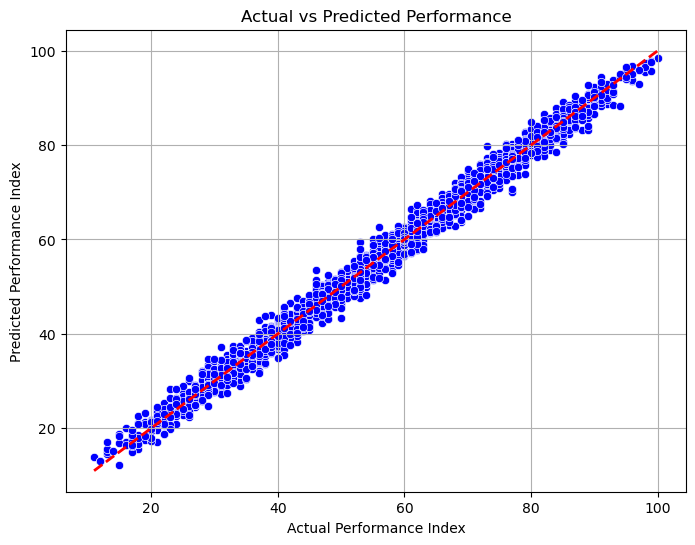

In [42]:
# Visualization: Actual vs Predicted

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=best_model.predict(X_test_scaled), color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title(f"Actual vs Predicted Performance")
plt.grid(True)
plt.show()

In [1]:
# Special Note:

# 	After evaluating several regression models, Multiple Linear Regression (MLR) was chosen over Ridge Regression for the final model. Although Ridge is a regularized form of linear regression designed to reduce the risk of overfitting, both models produced nearly identical MAE, RMSE, and R² metrics.

# 	The minimal difference in accuracy, given the similarity in metrics, indicates that the dataset did not consider multicollinearity or coefficient instability, which are the main issues Ridge aims to address.

# 	Therefore, Multiple Linear Regression was selected for the final model based on its ease of interpretation and computational simplicity as the best way to explain how each feature contributes to student performance without imposing additional complexity.